# CTU-UHB Intrapartum CTG Database — 한 레코드 단계별 해부

**목적.** `ctu-hub-ctgdb/`(PhysioNet *CTU-UHB Intrapartum Cardiotocography Database* v1.0.0)의 구조를
**한 명의 분만 기록(레코드 1001번)**을 처음부터 끝까지 따라가며 단계별로 이해한다.
계획서 **3.2절(공개 벤치마크 데이터셋의 이해)**의 전수 검증·요약 통계·그림의 재현 코드다.

**데이터셋 한 줄 요약.** 체코 University Hospital Brno 분만실에서 2010.4~2012.8에 수집된
9,164건의 분만 중 CTG 중 임상·기술 기준으로 선별된 **552건**의 공개 데이터셋이다
(Chudáček et al., *BMC Pregnancy and Childbirth*, 2014). 각 건은 분만 직전 최대 약 90분의
**태아 심박동(FHR)**과 **자궁수축(UC)** 신호를 4 Hz로 담고, 제대동맥혈 pH·Apgar 점수 등
출생 직후 아웃컴과 산모 위험인자 메타데이터가 붙어 있다.

**이 노트북의 단계**
1. 파일 구조 — WFDB 포맷 (`.hea` 텍스트 헤더 + `.dat` 바이너리)
2. 헤더 파싱 — 신호 명세(샘플링·게인·체크섬)와 임상 메타데이터
3. `.dat` 바이너리 읽기와 체크섬 검증
4. 파형 시각화 — 전체 모습 → 결측 구간 → 확대 → 기저선·변이도 → 분만 단계
5. 임상 라벨 연결 (제대동맥혈 pH, Apgar)
6. 552건 전체 요약 통계 (논문 Table 2 수치 재계산)

## 0. 준비

표준 과학 스택만 사용한다(numpy / pandas / matplotlib / scipy).
WFDB 리더 패키지(`pip install wfdb`)가 없어도 되도록, 이 데이터베이스의 바이너리 포맷이
단일 형식(format 16)이라는 점을 이용해 numpy로 직접 읽는다 — 어차피 내용을 뜯어보는 것이 목적이므로
직접 읽는 편이 구조 이해에도 낫다.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.signal import find_peaks

# 한글 폰트 (없으면 기본 폰트로 진행)
try:
    fm.findfont("NanumGothic", fallback_to_default=False)
    plt.rcParams["font.family"] = "NanumGothic"
except ValueError:
    pass
plt.rcParams["axes.unicode_minus"] = False

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "ctu-hub-ctgdb" / "RECORDS").exists():
            return p
    raise FileNotFoundError("ctu-hub-ctgdb 를 상위 디렉토리에서 찾지 못함")

REPO_ROOT = find_repo_root(Path.cwd())
DATA_DIR = REPO_ROOT / "ctu-hub-ctgdb"
print("데이터 경로:", DATA_DIR)

데이터 경로: /home/yabsed/Documents/summer26/fetalguard-ai/project/experiment-15/ctu-hub-ctgdb


## 1. 파일 구조 — 레코드 = `.hea` + `.dat` 한 쌍

PhysioNet의 표준 **WFDB(WaveForm DataBase) 포맷**을 쓴다. 레코드 한 건은 두 파일로 이루어진다.

- `NNNN.hea` — 텍스트 헤더. 신호 명세(포맷·게인·단위·체크섬)와 임상 메타데이터(주석)를 담는다.
- `NNNN.dat` — 바이너리 신호 본체. 이 DB에서는 전 레코드가 **format 16**(16-bit 정수, 채널 다중화)이다.
- `RECORDS` — 전체 레코드 ID 목록(552행). `SHA256SUMS.txt`는 파일 무결성 검증용 해시 목록이다.

In [2]:
records = (DATA_DIR / "RECORDS").read_text().split()
print(f"레코드 수: {len(records)}건 (ID 예: {records[:5]} ...)")

rid = "1001"
for f in sorted(DATA_DIR.glob(rid + ".*")):
    print(f"{f.name:12s} {f.stat().st_size:>10,} bytes")

print("\n[1001.hea 전문]")
print((DATA_DIR / f"{rid}.hea").read_text())

레코드 수: 552건 (ID 예: ['1001', '1002', '1003', '1004', '1005'] ...)
1001.dat         76,800 bytes
1001.hea            926 bytes

[1001.hea 전문]
1001 2 4 19200
1001.dat 16 100(0)/bpm 12 0 15050 20101 0 FHR
1001.dat 16 100/nd 12 0 700 378 0 UC

#----- Additional parameters for record 1001

#-- Outcome measures
#pH           7.14
#BDecf        8.14
#pCO2         7.7
#BE           -10.5
#Apgar1       6
#Apgar5       8

#-- !NotReadyYet! Neonatology outcome measures !NotReadyYet!
#NICU days    0
#Seizures     0
#HIE          0
#Intubation   0
#Main diag.   0
#Other diag.  0

#-- Fetus/Neonate descriptors
#Gest. weeks  37
#Weight(g)    2660
#Sex          2

#-- Maternal (risk-)factors
#Age          32
#Gravidity    1
#Parity       0
#Diabetes     1
#Hypertension 0
#Preeclampsia 0
#Liq. praecox 1
#Pyrexia      0
#Meconium     0

#-- Delivery descriptors
#Presentation 2
#Induced      0
#I.stage      232
#NoProgress   0
#CK/KP        0
#II.stage     20
#Deliv. type  1

#-- Signal information
#dbID 

**헤더 읽는 법 (레코드 1001 기준)**

- 1행 `1001 2 4 19200` — 레코드명, 신호 2개, 샘플링 **4 Hz**, 샘플 **19,200개** (= 19,200 / 4 / 60 = **80분**).
- 2행 `1001.dat 16 100(0)/bpm 12 0 15050 20101 0 FHR`
  — 파일명, format 16, 게인 **100**(디지털 100 = 1 bpm), ADC 기준점 0, 첫 샘플 디지털값 15050(→ 150.5 bpm),
  **체크섬 20101**, 신호명 **FHR**(태아 심박동).
- 3행 — 같은 형식으로 **UC**(uterine contraction, 자궁수축). 단위는 `nd`(tocodynamometer의 상대 단위, 사실상 임의 단위).
- `#` 이하 — 임상 메타데이터. 6개 그룹으로 구성된다:
  - *Outcome measures*: 출생 직후 **객관적 아웃컴** — 제대동맥혈 pH, BDecf, pCO₂, BE, 1분/5분 Apgar
  - *Neonatology outcome measures*: NICU 입원, 경련 등 (이 DB에서는 미확정 값, 전부 0)
  - *Fetus/Neonate descriptors*: 재태주수, 체중, 성별
  - *Maternal (risk-)factors*: 산모 나이·임신력·출산력, 당뇨·고혈압·자간전증·조기파막·발열·태변
  - *Delivery descriptors*: 태위, 유도분만 여부, 1·2기 분만 시간, 분만 형태
  - *Signal information*: dbID, 기록 유형(외부/내부 측정), **2기 분만 시작 위치**, 기록 끝~분만 간격

## 2. 헤더 파싱 — 신호 명세와 메타데이터를 구조화한다

앞으로 모든 분석의 입구가 될 파서를 만든다. 규칙은 단순하다:

1. 첫 줄 → 레코드 공통 정보 (신호 수, 샘플링 주파수, 샘플 수)
2. `#`으로 시작하지 않는 줄 → 신호별 명세 (9개 필드). 절 사이의 빈 줄은 건너뛴다.
3. `#`으로 시작하는 줄 → `키 값` 형태의 메타데이터 (단, `--`로 시작하는 절 제목 줄은 건너뛴다)

In [3]:
def parse_header(hea_path: Path):
    """WFDB .hea 파일을 (레코드 정보, 신호 명세 리스트, 메타데이터 dict)로 파싱."""
    lines = hea_path.read_text().splitlines()
    rec = lines[0].split()
    record = {"name": rec[0], "n_signals": int(rec[1]),
              "fs": float(rec[2]), "n_samples": int(rec[3])}

    signals, meta = [], {}
    for line in lines[1:]:
        if not line.strip():
            continue                  # 절 사이의 빈 줄 스킵
        if line.startswith("#"):
            text = line.lstrip("#").strip()
            if text.startswith("-"):      # 절 제목 줄 스킵
                continue
            m = re.match(r"^(.*?)\s+(-?[\d.]+|NaN)$", text)
            if m:
                meta[m.group(1).strip()] = float(m.group(2))
            continue
        p = line.split()
        gain = re.match(r"^([\d.]+)", p[2])
        unit = p[2].partition("/")[2]
        signals.append({
            "file": p[0], "format": int(p[1]),
            "gain": float(gain.group(1)), "unit": unit,
            "adc_zero": int(p[4]), "init_value": int(p[5]),
            "checksum": int(p[6]), "description": p[8],
        })
    return record, signals, meta

record, signals, meta = parse_header(DATA_DIR / f"{rid}.hea")

print(f"레코드 {record['name']}: 신호 {record['n_signals']}개, "
      f"{record['fs']:g} Hz, {record['n_samples']:,}샘플 "
      f"({record['n_samples'] / record['fs'] / 60:.1f}분)")
for s in signals:
    print(f"  [{s['description']}] format={s['format']}, gain={s['gain']:g}/{s['unit']}, "
          f"첫샘플 디지털={s['init_value']}, checksum={s['checksum']}")

groups = {
    "Outcome measures (출생 직후 아웃컴)": ["pH", "BDecf", "pCO2", "BE", "Apgar1", "Apgar5"],
    "Fetus/Neonate descriptors": ["Gest. weeks", "Weight(g)", "Sex"],
    "Maternal risk factors": ["Age", "Gravidity", "Parity", "Diabetes", "Hypertension",
                              "Preeclampsia", "Liq. praecox", "Pyrexia", "Meconium"],
    "Delivery descriptors": ["Presentation", "Induced", "I.stage", "NoProgress",
                             "CK/KP", "II.stage", "Deliv. type"],
    "Signal information": ["dbID", "Rec. type", "Pos. II.st.", "Sig2Birth"],
}
for g, keys in groups.items():
    print(f"\n■ {g}")
    for k in keys:
        print(f"  {k:14s} = {meta[k]:g}")

레코드 1001: 신호 2개, 4 Hz, 19,200샘플 (80.0분)
  [FHR] format=16, gain=100/bpm, 첫샘플 디지털=15050, checksum=20101
  [UC] format=16, gain=100/nd, 첫샘플 디지털=700, checksum=378

■ Outcome measures (출생 직후 아웃컴)
  pH             = 7.14
  BDecf          = 8.14
  pCO2           = 7.7
  BE             = -10.5
  Apgar1         = 6
  Apgar5         = 8

■ Fetus/Neonate descriptors
  Gest. weeks    = 37
  Weight(g)      = 2660
  Sex            = 2

■ Maternal risk factors
  Age            = 32
  Gravidity      = 1
  Parity         = 0
  Diabetes       = 1
  Hypertension   = 0
  Preeclampsia   = 0
  Liq. praecox   = 1
  Pyrexia        = 0
  Meconium       = 0

■ Delivery descriptors
  Presentation   = 2
  Induced        = 0
  I.stage        = 232
  NoProgress     = 0
  CK/KP          = 0
  II.stage       = 20
  Deliv. type    = 1

■ Signal information
  dbID           = 974204
  Rec. type      = 1
  Pos. II.st.    = 14400
  Sig2Birth      = 0


## 3. `.dat` 바이너리 읽기와 체크섬 검증

**format 16**은 16-bit 부호 있는 정수(little-endian)를 채널별로 번갈아 저장하는 방식이다.
샘플 1개 시점마다 `[FHR, UC]` 2개의 int16이 나란히 기록되므로, 파일 크기는
`19,200샘플 × 2채널 × 2바이트 = 76,800바이트`가 된다 (위 1단계의 실제 파일 크기와 일치한다).

물리 단위로의 변환: **물리값 = 디지털값 ÷ gain** (이 DB는 ADC 기준점이 0이라 이것으로 끝).
헤더의 첫 샘플 값(init value)과 체크섬(신호 샘플 총합 mod 65,536)으로 **읽기가 올바른지 검증**한다.

In [4]:
def read_signals(hea_path: Path):
    """format 16 .dat를 읽어 {신호명: 물리단위 배열} dict 반환. 체크섬·첫샘플 검증 포함."""
    record, signals, meta = parse_header(hea_path)
    raw = np.fromfile(hea_path.with_suffix(".dat"), dtype="<i2")
    raw = raw.reshape(-1, record["n_signals"])

    out = {}
    for i, s in enumerate(signals):
        digital = raw[:, i].astype(np.int64)
        assert digital[0] == s["init_value"], f"{s['description']} 첫 샘플 불일치"
        assert digital.sum() % 65536 == s["checksum"] % 65536, f"{s['description']} 체크섬 불일치"
        out[s["description"]] = digital / s["gain"]   # adc_zero = 0 in this DB
    return record, meta, out

record, meta, sig = read_signals(DATA_DIR / f"{rid}.hea")
for name, x in sig.items():
    print(f"{name}: {len(x):,}샘플, 범위 {x.min():.1f}~{x.max():.1f}, "
          f"첫 값 {x[0]:.2f} (헤더 명세와 일치 — 읽기 검증 통과)")

FHR: 19,200샘플, 범위 0.0~193.0, 첫 값 150.50 (헤더 명세와 일치 — 읽기 검증 통과)
UC: 19,200샘플, 범위 0.0~127.0, 첫 값 7.00 (헤더 명세와 일치 — 읽기 검증 통과)


- **FHR**은 bpm 단위이며, 정상 범위(기저선 110~160 bpm) 부근의 값이 나온다. 0은 '심박수 0'이 아니라
  **신호 소실(결측)**이라는 점이 중요하다 — 5단계에서 다룬다.
- **UC**는 tocodynamometer 출력의 상대 단위다. 수축이 있을 때 올라가는 곡선이며 절대값의 의미는 없다.

## 4. 한 레코드의 전체 모습

80분짜리 기록 전체를 펼쳐 본다. 위가 FHR, 아래가 UC다.

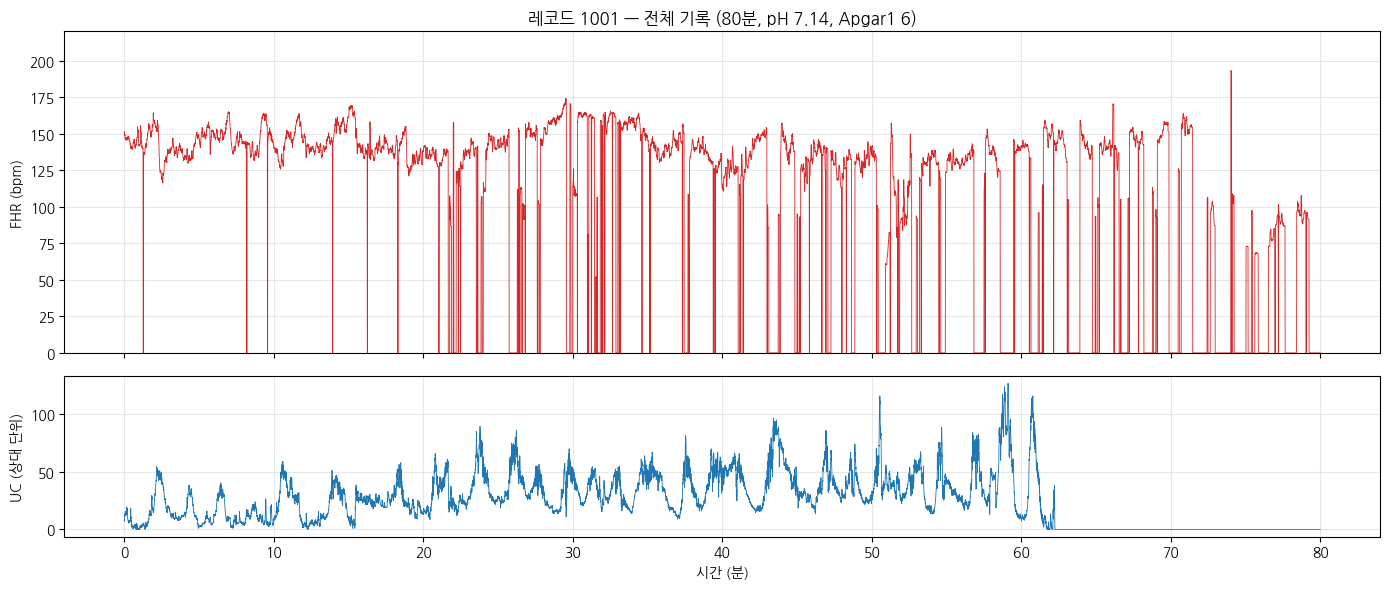

In [5]:
n = record["n_samples"]
t_min = np.arange(n) / record["fs"] / 60   # 분 단위 시간축

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(t_min, sig["FHR"], lw=0.6, color="tab:red")
axes[0].set_ylabel("FHR (bpm)")
axes[0].set_ylim(0, 220)
axes[0].set_title(f"레코드 {rid} — 전체 기록 ({n / record['fs'] / 60:.0f}분, "
                  f"pH {meta['pH']:.2f}, Apgar1 {meta['Apgar1']:.0f})")
axes[1].plot(t_min, sig["UC"], lw=0.6, color="tab:blue")
axes[1].set_ylabel("UC (상대 단위)")
axes[1].set_xlabel("시간 (분)")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "01_full_trace.png", dpi=120, bbox_inches="tight")
plt.show()

눈에 띄는 것:

- FHR 곡선이 **0으로 곤두박질치는 구간**들이 있다 → 센서 접촉 불량 등으로 신호가 끊긴 결측 구간이다.
- UC는 분만이 가까워질수록(오른쪽으로 갈수록) 주기적인 봉우리가 뚜렷해진다.
- FHR의 일시적 하강(감속, deceleration)이 UC 봉우리와 시간적으로 어떻게 얽히는지가 CTG 판독의 핵심이다.

## 5. 결측 구간 — 0은 심박수가 아니다

FHR = 0은 생리적으로 불가능한 값이며, 모니터가 태아 신호를 잡지 못한 **신호 소실(signal loss)**이다.
결측을 0 그대로 두고 평균·표준편차 등을 계산하면 크게 왜곡되므로, 분석 전에는 NaN으로 바꿔 다룬다.
구글 팀(3.3절)의 전처리도 이 구간 식별에서 출발한다(≤15초 결측은 선형 보간, 더 긴 결측은 0 유지).

FHR 결측: 4,255샘플 = 전체의 22.2% (17.7분)
결측 구간 109개 (최대 63초)


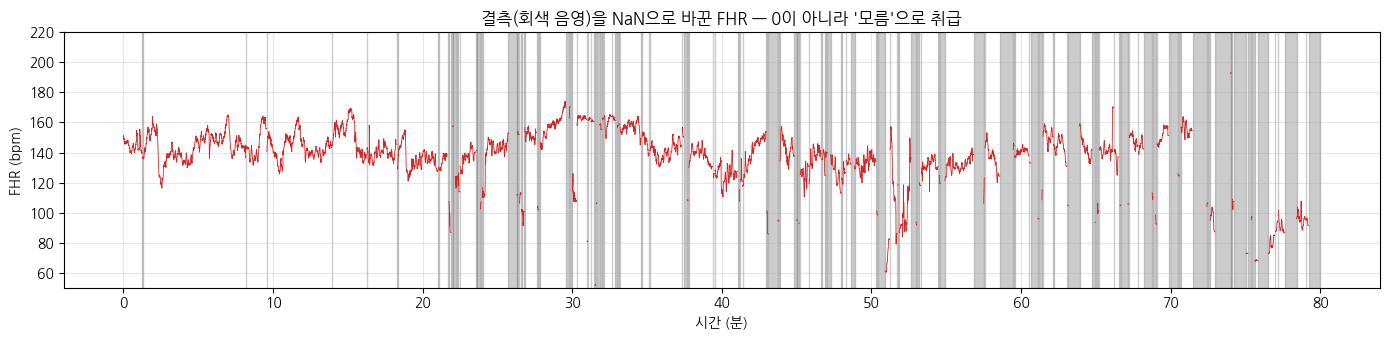

In [6]:
fhr, uc = sig["FHR"], sig["UC"]
missing = fhr == 0
print(f"FHR 결측: {missing.sum():,}샘플 = 전체의 {missing.mean() * 100:.1f}% "
      f"({missing.sum() / record['fs'] / 60:.1f}분)")

# 결측 구간(연속된 0의 덩어리) 목록
d = np.diff(missing.astype(int))
starts = list(np.where(d == 1)[0] + 1)
ends = list(np.where(d == -1)[0] + 1)
if missing[0]:
    starts = [0] + starts
if missing[-1]:
    ends = ends + [len(missing)]
gap_min = [(s / record["fs"] / 60, (e - s) / record["fs"]) for s, e in zip(starts, ends)]
print(f"결측 구간 {len(gap_min)}개 (최대 {max(g[1] for g in gap_min):.0f}초)")

fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(t_min, np.where(missing, np.nan, fhr), lw=0.6, color="tab:red")
for (s_min, dur), s_idx in zip(gap_min, starts):
    ax.axvspan(s_min, s_min + dur / 60, color="gray", alpha=0.4)
ax.set_ylim(50, 220)
ax.set_xlabel("시간 (분)")
ax.set_ylabel("FHR (bpm)")
ax.set_title("결측(회색 음영)을 NaN으로 바꾼 FHR — 0이 아니라 '모름'으로 취급")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "02_missing.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. 확대해서 보기 — 수축과 심박수의 시간 관계

CTG 판독의 본질은 두 신호의 **시간 관계**다. 10분 창으로 확대해 UC 봉우리(자궁수축)와
FHR의 상승(가속)/하강(감속)이 어떻게 엇갈리는지 본다.

- **조기감속(early)**: 수축과 동시에 시작·회복 — 두부 압박, 대개 무해
- **후기감속(late)**: 수축 정점 이후에 지연되어 최저점 — 자궁·태반 혈류 저하의 경고 신호

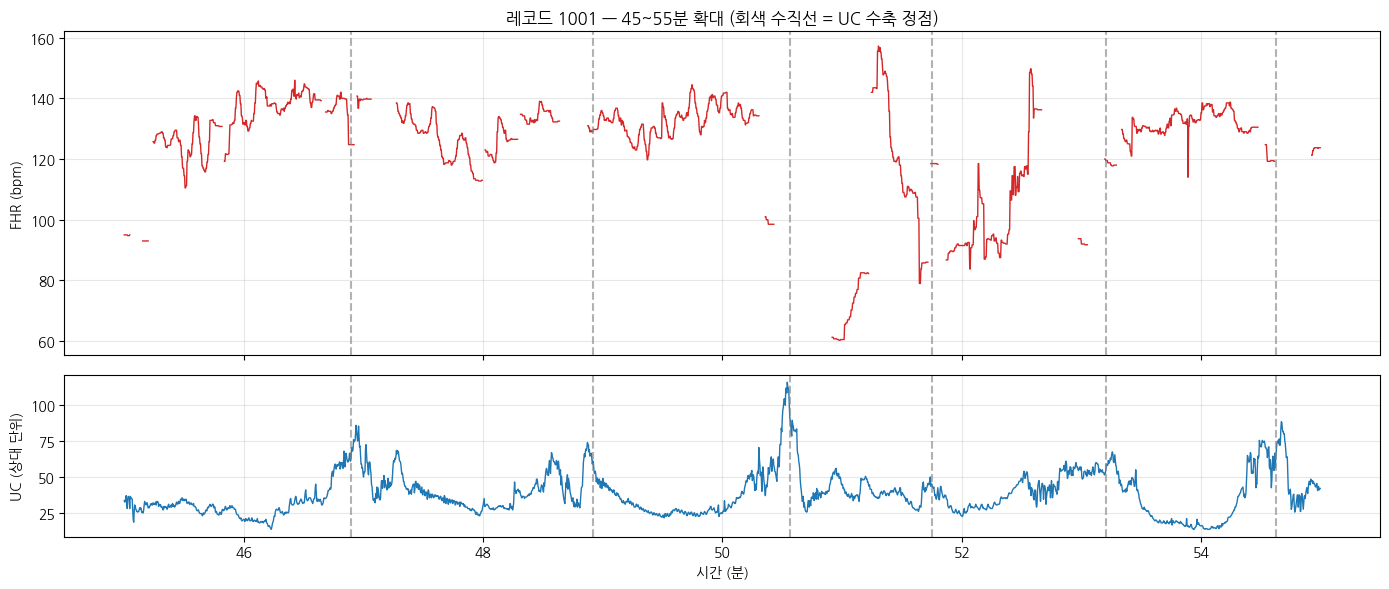

이 창에서 감지된 자궁수축: 6회


In [7]:
win = (45, 55)   # 확대할 10분 창 (분)
m = (t_min >= win[0]) & (t_min < win[1])
fhr_w = np.where(missing, np.nan, fhr)
uc_s = pd.Series(uc).rolling(40, center=True, min_periods=1).mean().to_numpy()  # 10초 평활
peaks, _ = find_peaks(uc_s, distance=int(60 * record["fs"]), prominence=3)
peaks = peaks[m[peaks]]

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(t_min[m], fhr_w[m], lw=1.0, color="tab:red")
axes[0].set_ylabel("FHR (bpm)")
axes[0].set_title(f"레코드 {rid} — {win[0]}~{win[1]}분 확대 (회색 수직선 = UC 수축 정점)")
axes[1].plot(t_min[m], uc[m], lw=1.0, color="tab:blue")
axes[1].set_ylabel("UC (상대 단위)")
axes[1].set_xlabel("시간 (분)")
for ax in axes:
    for p in peaks:
        ax.axvline(t_min[p], color="gray", ls="--", alpha=0.6)
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_zoom.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"이 창에서 감지된 자궁수축: {len(peaks)}회")

수직 점선(수축 정점)을 기준으로 FHR 곡선의 최저점이 **정점과 겹치는지, 뒤로 밀리는지**를 보면 된다.
이 레코드(pH 7.14, 비정상 아웃컴)에서는 수축 뒤로 지연되는 하강이 반복된다 — 9단계에서 라벨과 연결한다.

## 7. 기저심박수(baseline)와 변이도(variability)

임상 판독의 첫 두 축은:

- **기저심박수**: 가속·감속을 제외한 평균 심박수 (정상 110~160 bpm)
- **변이도**: 기저선 주위의 잔잔한 진폭 (분당 6~25 bpm이 중등도, ≤5 bpm 소실은 위험 소견)

여기서는 개념 확인용으로 10분 이동 중앙값을 기저선 근사로 쓴다
(정식 추출법은 가속·감속을 반복적으로 제외하며 수렴시키는 방식 — `../2-google-reproduction/features.py`와
`../3-poc-factor-extraction/extract_factors_ctu.py`의 FIGO 반복 기저선 참조).

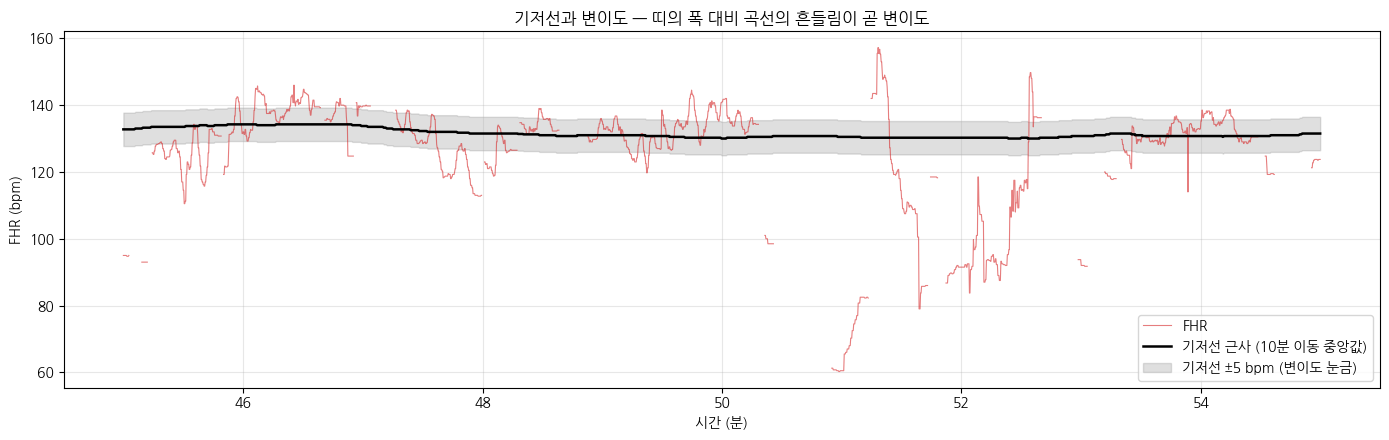

In [8]:
baseline = pd.Series(fhr_w).rolling(int(600 * record["fs"]), center=True,
                                    min_periods=int(60 * record["fs"])).median().to_numpy()

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.plot(t_min[m], fhr_w[m], lw=0.8, color="tab:red", alpha=0.6, label="FHR")
ax.plot(t_min[m], baseline[m], lw=1.8, color="black", label="기저선 근사 (10분 이동 중앙값)")
ax.fill_between(t_min[m], baseline[m] - 5, baseline[m] + 5, color="gray", alpha=0.25,
                label="기저선 ±5 bpm (변이도 눈금)")
ax.set_ylabel("FHR (bpm)")
ax.set_xlabel("시간 (분)")
ax.set_title("기저선과 변이도 — 띠의 폭 대비 곡선의 흔들림이 곧 변이도")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "04_baseline.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. 기록 속의 분만 단계 — `Pos. II.st.`와 `Sig2Birth`

- `Pos. II.st.` — **2기 분만(완전 개방~분만) 시작 위치** (샘플 인덱스). 레코드 1001은 14,400 = 60분 지점.
- `Sig2Birth` — 기록 끝에서 분만까지의 시간(분). 0이면 기록 끝이 곧 분만이다.

즉 이 DB의 대부분 기록은 **분만 시점으로 거슬러 올라가는 최대 90분**의 말단 분만 기록이다.
구글 팀이 '분만 직전 마지막 30분'을 기준 구간으로 삼은 이유이기도 하다.

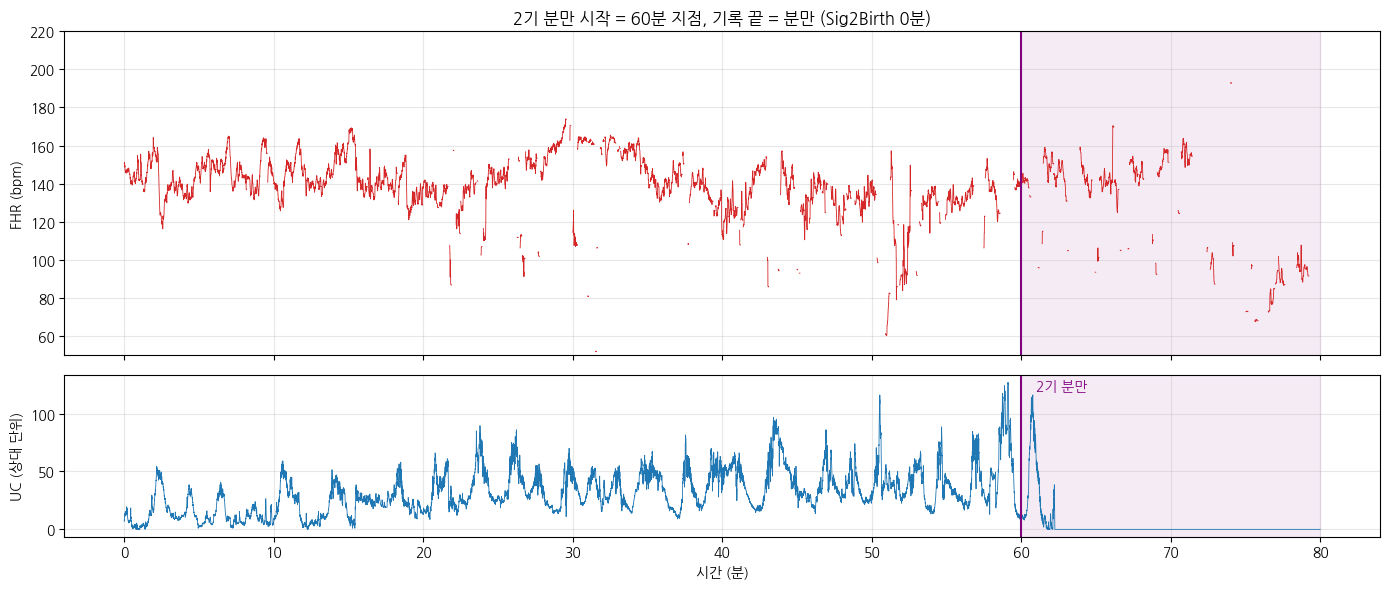

In [9]:
ii_stage_min = meta["Pos. II.st."] / record["fs"] / 60
end_min = n / record["fs"] / 60

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(t_min, fhr_w, lw=0.6, color="tab:red")
axes[0].set_ylabel("FHR (bpm)")
axes[0].set_ylim(50, 220)
axes[0].set_title(f"2기 분만 시작 = {ii_stage_min:.0f}분 지점, 기록 끝 = 분만 "
                  f"(Sig2Birth {meta['Sig2Birth']:.0f}분)")
axes[1].plot(t_min, uc, lw=0.6, color="tab:blue")
axes[1].set_ylabel("UC (상대 단위)")
axes[1].set_xlabel("시간 (분)")
for ax in axes:
    ax.axvline(ii_stage_min, color="purple", lw=1.5)
    ax.axvspan(ii_stage_min, end_min, color="purple", alpha=0.08)
    ax.grid(alpha=0.3)
axes[1].text(ii_stage_min + 1, axes[1].get_ylim()[1] * 0.9, "2기 분만", color="purple")
fig.tight_layout()
fig.savefig(FIG_DIR / "05_stages.png", dpi=120, bbox_inches="tight")
plt.show()

## 9. 이 기록의 임상 라벨 — 파형이 아웃컴과 어떻게 연결되는가

CTG 파형 자체에는 정답이 없다. 학습 신호는 **출생 직후 측정된 아웃컴**에서 온다.
구글 팀(Chiou et al., 2025)의 라벨 정의:

| 라벨 | 정의 | 해석 |
|---|---|---|
| pH | 제대동맥혈 pH < 7.20 | **객관적** 태아 저산소증 지표 |
| Apgar | 1분 Apgar < 7 | 임상의의 **주관적** 신생아 평가 |
| LOR | pH 이상 **OR** Apgar 이상 | Ogasawara et al.(2021)의 복합 기준 |

레코드 1001은 pH 7.14 < 7.20, Apgar1 6 < 7 — **두 기준 모두 비정상**이다.
4·6단계에서 본 반복적 감속 패턴이 실제 산증 아웃컴과 대응하는 사례다.

In [10]:
ph, apgar1 = meta["pH"], meta["Apgar1"]
labels = {"pH<7.20": ph < 7.20, "Apgar1<7": apgar1 < 7}
labels["LOR"] = labels["pH<7.20"] or labels["Apgar1<7"]
for k, v in labels.items():
    print(f"{k:10s} → {'비정상(1)' if v else '정상(0)'}")

pH<7.20    → 비정상(1)
Apgar1<7   → 비정상(1)
LOR        → 비정상(1)


## 10. 552건 전체로 확장 — 데이터셋 요약 통계

같은 파서를 552개 헤더 전부에 돌려 데이터셋의 전체 윤곽을 잡는다.
아래 수치들은 구글 논문 Table 2의 값들과 대조할 수 있다.

In [11]:
rows = []
for name in records:
    r, m, s = read_signals(DATA_DIR / f"{name}.hea")
    miss = (s["FHR"] == 0).mean()
    rows.append({
        "record": name, "minutes": r["n_samples"] / r["fs"] / 60,
        "fhr_missing_pct": miss * 100,
        "pH": m["pH"], "Apgar1": m["Apgar1"], "Apgar5": m["Apgar5"],
        "Gest. weeks": m["Gest. weeks"], "Age": m["Age"], "Parity": m["Parity"],
        "Diabetes": m["Diabetes"], "Hypertension": m["Hypertension"],
        "Preeclampsia": m["Preeclampsia"], "Liq. praecox": m["Liq. praecox"],
        "Pyrexia": m["Pyrexia"], "Meconium": m["Meconium"],
        "Induced": m["Induced"], "Deliv. type": m["Deliv. type"],
        "Rec. type": m["Rec. type"],
    })
df = pd.DataFrame(rows).set_index("record")

df["label_pH"] = df["pH"] < 7.20
df["label_Apgar"] = df["Apgar1"] < 7
df["label_LOR"] = df["label_pH"] | df["label_Apgar"]

print(f"총 {len(df)}건, 총 기록 시간 ≈ {df['minutes'].sum():,.0f}분")
print(f"기록 길이: 평균 {df['minutes'].mean():.1f}분 (중앙 {df['minutes'].median():.1f}, "
      f"범위 {df['minutes'].min():.1f}~{df['minutes'].max():.1f})")
print(f"FHR 결측률: 평균 {df['fhr_missing_pct'].mean():.1f}% "
      f"(중앙 {df['fhr_missing_pct'].median():.1f}%)")
print()
for col in ["label_pH", "label_Apgar", "label_LOR"]:
    n_pos = df[col].sum()
    print(f"{col:12s}: 비정상 {n_pos:3d}건 ({n_pos / len(df) * 100:.1f}%) / 정상 {len(df) - n_pos}건")
print()
print("산모 위험인자·분만 속성 (해당 건수):")
for col in ["Diabetes", "Hypertension", "Preeclampsia", "Liq. praecox",
            "Pyrexia", "Meconium", "Induced"]:
    print(f"  {col:14s} {df[col].sum():4.0f}건")
print(f"  분만 형태      질식분만 {int((df['Deliv. type'] == 1).sum())}건 / "
      f"제왕절개 등 {int((df['Deliv. type'] != 1).sum())}건")

총 552건, 총 기록 시간 ≈ 40,938분
기록 길이: 평균 74.2분 (중앙 71.7, 범위 60.0~90.1)
FHR 결측률: 평균 18.8% (중앙 18.3%)

label_pH    : 비정상 177건 (32.1%) / 정상 375건
label_Apgar : 비정상  68건 (12.3%) / 정상 484건
label_LOR   : 비정상 198건 (35.9%) / 정상 354건

산모 위험인자·분만 속성 (해당 건수):
  Diabetes         37건
  Hypertension     44건
  Preeclampsia     17건
  Liq. praecox    147건
  Pyrexia           6건
  Meconium         64건
  Induced         217건
  분만 형태      질식분만 506건 / 제왕절개 등 46건


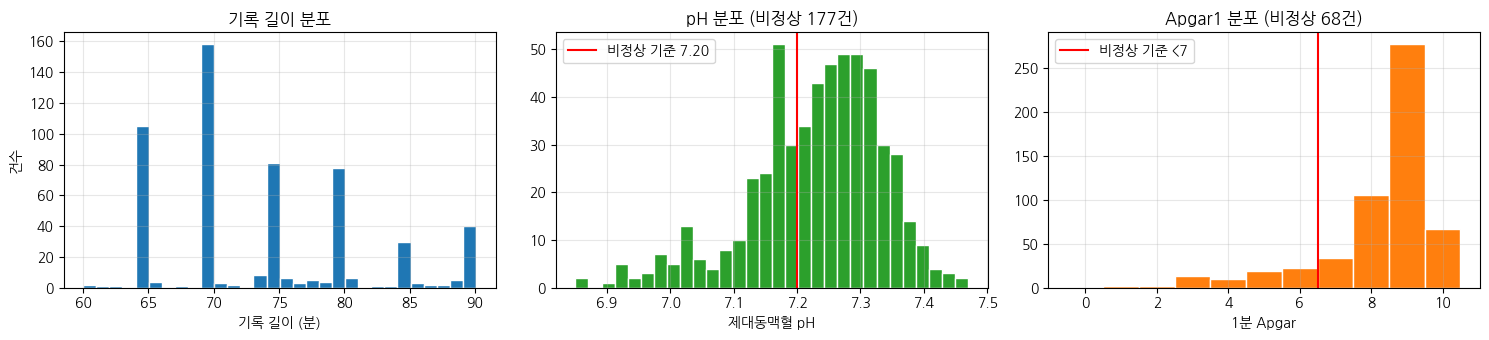

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].hist(df["minutes"], bins=30, color="tab:blue", edgecolor="white")
axes[0].set_xlabel("기록 길이 (분)")
axes[0].set_ylabel("건수")
axes[0].set_title("기록 길이 분포")
axes[1].hist(df["pH"], bins=30, color="tab:green", edgecolor="white")
axes[1].axvline(7.20, color="red", lw=1.5, label="비정상 기준 7.20")
axes[1].set_xlabel("제대동맥혈 pH")
axes[1].legend()
axes[1].set_title(f"pH 분포 (비정상 {df['label_pH'].sum()}건)")
axes[2].hist(df["Apgar1"], bins=np.arange(-0.5, 11), color="tab:orange", edgecolor="white")
axes[2].axvline(6.5, color="red", lw=1.5, label="비정상 기준 <7")
axes[2].set_xlabel("1분 Apgar")
axes[2].legend()
axes[2].set_title(f"Apgar1 분포 (비정상 {df['label_Apgar'].sum()}건)")
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "06_dataset_dist.png", dpi=120, bbox_inches="tight")
plt.show()

마지막으로, 두 개의 대표 사례를 나란히 놓는다: 지금까지 뜯어본 **비정상 레코드 1001**(pH 7.14, Apgar 6)과,
기준을 모두 여유 있게 통과한 **정상 레코드**의 분만 직전 30분. 구글 논문 Fig. 3c의 대응 그림이다.

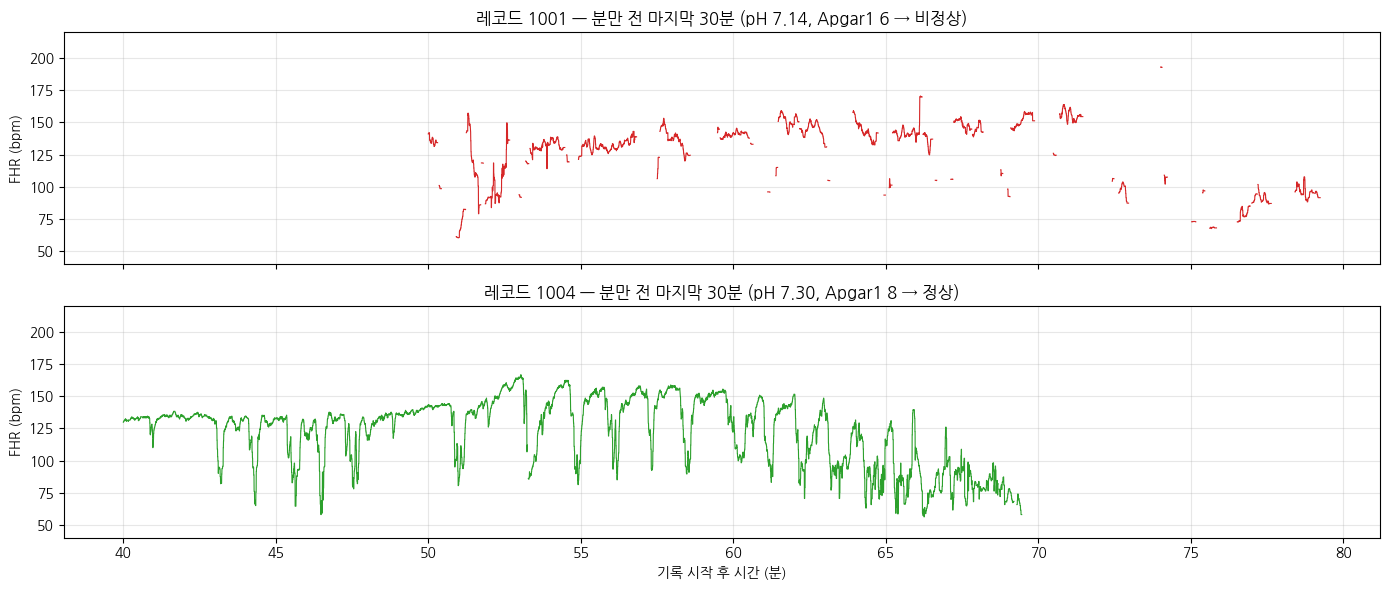

대조 정상 레코드: 1004


In [13]:
normal_id = df[(df["pH"] >= 7.30) & (df["Apgar1"] >= 8)].index[0]
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, name, color in [(axes[0], rid, "tab:red"), (axes[1], normal_id, "tab:green")]:
    r, m, s = read_signals(DATA_DIR / f"{name}.hea")
    fs = r["fs"]
    f = np.where(s["FHR"] == 0, np.nan, s["FHR"])
    t = np.arange(r["n_samples"]) / fs / 60
    last30 = t >= t[-1] - 30
    ax.plot(t[last30], f[last30], lw=0.8, color=color)
    ax.set_ylabel("FHR (bpm)")
    ax.set_ylim(40, 220)
    ax.grid(alpha=0.3)
    ax.set_title(f"레코드 {name} — 분만 전 마지막 30분 "
                 f"(pH {m['pH']:.2f}, Apgar1 {m['Apgar1']:.0f} → "
                 f"{'비정상' if (m['pH'] < 7.2 or m['Apgar1'] < 7) else '정상'})")
axes[1].set_xlabel("기록 시작 후 시간 (분)")
fig.tight_layout()
fig.savefig(FIG_DIR / "07_normal_vs_abnormal.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"대조 정상 레코드: {normal_id}")

## 정리

한 레코드(한 row)의 구조를 끝까지 따라가 봤다.

1. **파일** — 레코드 = `.hea`(텍스트 헤더) + `.dat`(format 16 바이너리). 552건.
2. **신호** — FHR(bpm)과 UC(상대 단위), 4 Hz, 분만 직전 최대 ~90분. 0은 결측이다.
3. **메타데이터** — 헤더 주석 안에 아웃컴(pH·Apgar)·태아 속성·산모 위험인자·분만 속성이 함께 있다.
4. **라벨** — pH < 7.20 (177건 비정상, 32%), Apgar1 < 7 (68건, 12%), LOR (198건, 36%).
5. **구글 팀과의 연결** — 이 데이터 위에서 Chiou et al.(2025)은 마지막 30분 크롭 → 1 Hz 다운샘플 →
   CNN(CTG-net)으로 pH/Apgar/LOR를 예측했다. 그 전처리·특성·모델 재구현 코드가 `../2-google-reproduction/`이다.

다음 단계: 계획서 5.1절의 28개 인자(Cat28) 추출은 `../3-poc-factor-extraction/` 참조 —
샘플 한 건을 눈으로 따라가는 노트북은 `cat28_walkthrough.ipynb`다.